# TP7 — NLP : Eco-Smart Classifier
## Module 4 : Traitement Automatique du Langage Naturel (NLP)

**Objectif :** Classifier automatiquement la colonne `Rapport_Collecte` en catégories de déchets (Papier, Plastique, Verre, Métal) en utilisant des techniques NLP classiques et avancées.

**Dataset :** `dataset_ProjetML_2026.csv` (10 500 échantillons, 9 colonnes)

---

In [1]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, mean_absolute_error, r2_score)
from scipy.sparse import issparse, hstack as sparse_hstack

from gensim.models import Word2Vec

import spacy

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("All imports OK")

All imports OK


## Chargement du dataset

In [2]:
CSV_PATH = "../backend/dataset_ProjetML_2026.csv"
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (10500, 9)


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


In [3]:
df.info()
print("\nValeurs manquantes :")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB

Valeurs manquantes :
Poids               1029
Volume               540
Conductivite        1017
Opacite             1035
Rigidite             558
Prix_Revente         536
Categorie            514
Source               536
Rapport_Collecte       0
dtype: int64


---
# Partie 1 — Prétraitement et Baseline Statistique
## 1.1 Nettoyage et Normalisation du texte

### Exploration du texte brut `Rapport_Collecte`

In [4]:
# Afficher des exemples bruts
print("=== Exemples de Rapport_Collecte bruts ===\n")
for i, txt in enumerate(df["Rapport_Collecte"].dropna().head(6)):
    print(f"[{i}] {txt}\n")

=== Exemples de Rapport_Collecte bruts ===

[0] Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau souple, non conducteur, aspect très opaque. Bon état général.

[1] Lot plastique à l'Usine A. Volume 64.7 L, poids 47.3 kg. Aspect indéterminée, rigidité moyenne. Aucune trace de métal.

[2] Bris de verre ou contenants en provenance de l'Usine B. Masse non mesuré kg. Matériau dense, rigidité élevée, transparence partielle. Légère contamination observée.

[3] Feuilles et cartons collectés au Centre de Tri. Masse totale non mesuré kg. Matériau léger, souple et opaque. Lot conforme aux standards de tri.

[4] Déchet de type papier identifié à l'Usine B. Volume estimé 59.5 L, poids non mesuré kg. Texture de rigidité non mesurée, très opaque.

[5] Déchet plastique collecté à l'Usine B. Poids 33.0 kg, volume 44.0 L. Rigidité semi-rigide, non conducteur. Surface légèrement translucide.



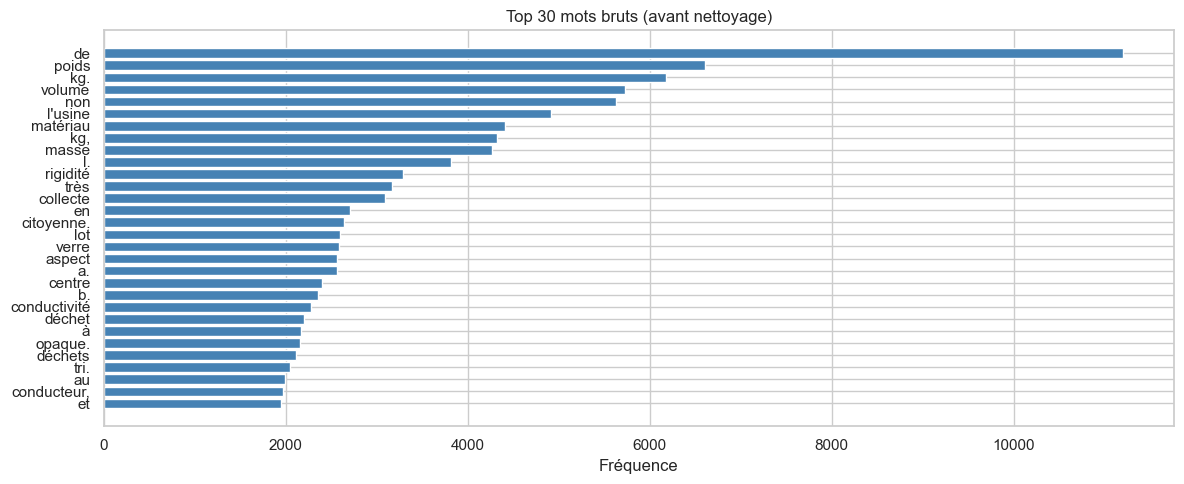


Observation : mots très fréquents comme 'de', 'kg', 'non', etc. = bruit à supprimer.


In [5]:
# Analyse du bruit : fréquence des mots AVANT nettoyage
from collections import Counter
all_words_raw = " ".join(df["Rapport_Collecte"].dropna()).lower().split()
raw_freq = Counter(all_words_raw).most_common(30)

fig, ax = plt.subplots(figsize=(12, 5))
words, counts = zip(*raw_freq)
ax.barh(words[::-1], counts[::-1], color="steelblue")
ax.set_title("Top 30 mots bruts (avant nettoyage)")
ax.set_xlabel("Fréquence")
plt.tight_layout()
plt.show()

print("\nObservation : mots très fréquents comme 'de', 'kg', 'non', etc. = bruit à supprimer.")

### Pourquoi NE PAS supprimer les nombres liés aux unités avant l'extraction ?

> Les valeurs numériques liées aux unités (ex: "16.7 kg", "64.7 L") contiennent de l'information
> discriminante pour la classification. Par exemple, un poids élevé (> 100 kg) est plus souvent
> associé au Métal, tandis qu'un faible poids est typique du Papier.
>
> **Cependant**, pour la vectorisation textuelle pure (TF-IDF, Word2Vec), on les supprime car
> les chiffres ajoutent du bruit au vocabulaire. L'extraction de ces valeurs se fera séparément
> dans la Partie 2.2 (extraction d'attributs via regex).

### Pipeline de nettoyage

In [6]:
# Domain-specific stopwords
DOMAIN_STOPWORDS = {"dechet", "collecte", "rapport", "materiau", "echantillon"}

# Load French spaCy model
nlp_model = spacy.load("fr_core_news_md", disable=["ner", "parser"])
SPACY_STOPS = nlp_model.Defaults.stop_words

def clean_text(text):
    """Lowercase, strip punctuation, digits, extra whitespace."""
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text):
    """Full preprocessing: clean -> tokenize -> remove stopwords -> lemmatize."""
    cleaned = clean_text(text)
    if not cleaned:
        return []
    doc = nlp_model(cleaned)
    tokens = []
    for token in doc:
        lemma = token.lemma_.lower().strip()
        if (not lemma or lemma in SPACY_STOPS
                or lemma in DOMAIN_STOPWORDS or len(lemma) <= 1):
            continue
        tokens.append(lemma)
    return tokens

print("Pipeline définie.")

Pipeline définie.


In [7]:
# Apply preprocessing
df_clean = df.dropna(subset=["Categorie", "Rapport_Collecte"]).copy()

print("Prétraitement en cours (spaCy)... Patientez.")
df_clean["tokens"] = df_clean["Rapport_Collecte"].apply(preprocess)
df_clean["text_clean"] = df_clean["tokens"].apply(lambda t: " ".join(t))

# Before/after
print("\n=== Avant / Après ===")
for i in range(3):
    row = df_clean.iloc[i]
    print(f"\nBRUT  : {row['Rapport_Collecte'][:100]}...")
    print(f"CLEAN : {row['text_clean'][:100]}...")
print(f"\nTotal documents: {len(df_clean)}")

Prétraitement en cours (spaCy)... Patientez.

=== Avant / Après ===

BRUT  : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau so...
CLEAN : lot papier récupérer site non renseigné poids léger kilogramme volume moyen matériau souple non cond...

BRUT  : Lot plastique à l'Usine A. Volume 64.7 L, poids 47.3 kg. Aspect indéterminée, rigidité moyenne. Aucu...
CLEAN : lot plastique usine volume poids kilogramme aspect indéterminé rigidité moyen aucun trace métal...

BRUT  : Bris de verre ou contenants en provenance de l'Usine B. Masse non mesuré kg. Matériau dense, rigidit...
CLEAN : bris verre contenant provenance usine masse non mesurer kilogramme matériau dense rigidité élevé tra...

Total documents: 9986


---
## 1.2 Vectorisation TF-IDF (Baseline)

In [8]:
# TF-IDF with (1,2)-grams, max 500 features (as per TP)
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
X_tfidf = tfidf.fit_transform(df_clean["text_clean"])

print(f"Matrice TF-IDF : {X_tfidf.shape}")
print(f"\nTop 20 features : {tfidf.get_feature_names_out()[:20].tolist()}")

Matrice TF-IDF : (9986, 500)

Top 20 features : ['absent', 'absent conteneur', 'acheminement', 'acheminement prioritaire', 'agent', 'anomalie', 'anomalie signaler', 'anormalement', 'anormalement élevé', 'aspect', 'aspect indéterminé', 'aspect légèrement', 'aspect opaque', 'aspect semi', 'aucun', 'aucun anomalie', 'aucun trace', 'bon', 'bon valeur', 'bon état']


---
## 1.3 Évaluation ML sur TF-IDF

In [9]:
# Encode labels + split
le = LabelEncoder()
y = le.fit_transform(df_clean["Categorie"].values)
classes = le.classes_

X_tr, X_te, y_tr, y_te = train_test_split(
    X_tfidf, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_tr.shape[0]}  Test: {X_te.shape[0]}  Classes: {list(classes)}")

Train: 7988  Test: 1998  Classes: ['Métal', 'Papier', 'Plastique', 'Verre']


In [10]:
# Train classifiers on TF-IDF
tfidf_results = {}

models_tfidf = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "LinearSVC": LinearSVC(max_iter=2000, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
}

for name, clf in models_tfidf.items():
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    acc = accuracy_score(y_te, preds)
    f1 = f1_score(y_te, preds, average="macro")
    cm = confusion_matrix(y_te, preds)
    tfidf_results[name] = {"acc": acc, "f1": f1, "cm": cm, "clf": clf, "preds": preds}
    print(f"{name:<22s}  Accuracy={acc:.4f}  F1-macro={f1:.4f}")

RandomForest            Accuracy=1.0000  F1-macro=1.0000
LinearSVC               Accuracy=1.0000  F1-macro=1.0000
LogisticRegression      Accuracy=1.0000  F1-macro=1.0000


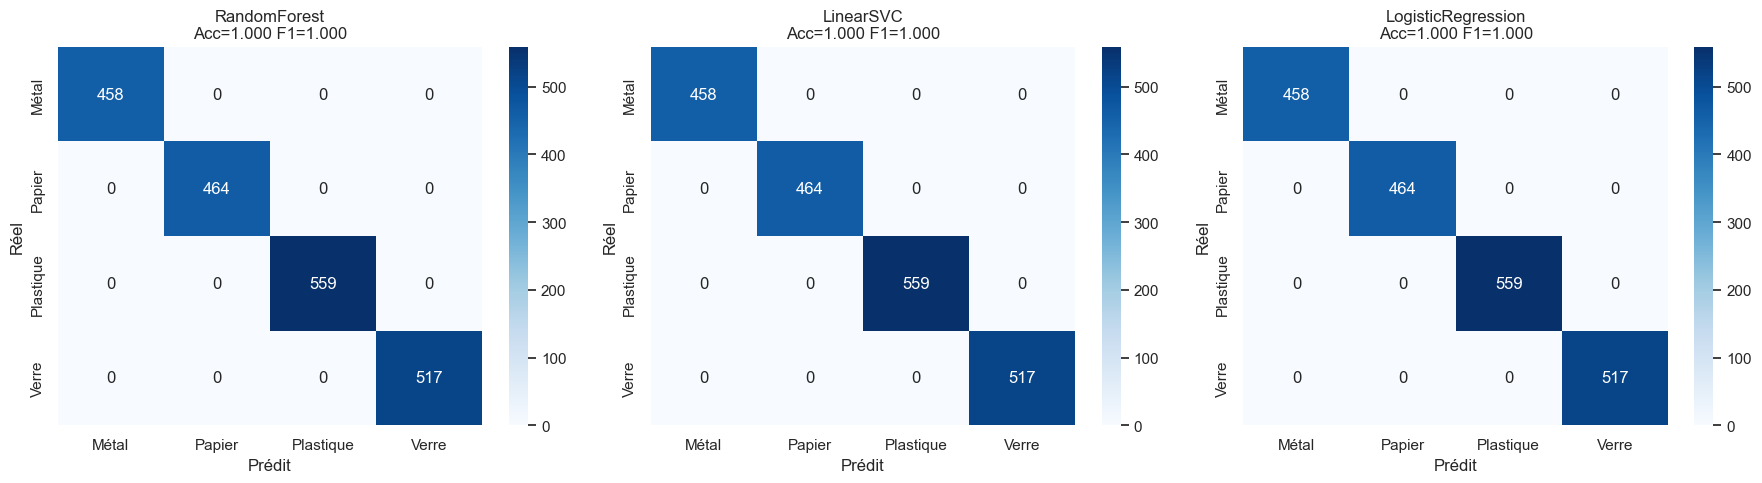


Meilleur modèle TF-IDF: RandomForest
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998



In [11]:
# Confusion matrices
fig, axes = plt.subplots(1, len(tfidf_results), figsize=(6*len(tfidf_results), 5))
if len(tfidf_results) == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, tfidf_results.items()):
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f"{name}\nAcc={r['acc']:.3f} F1={r['f1']:.3f}")
    ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")

plt.tight_layout()
plt.show()

# Best TF-IDF model report
best_tfidf = max(tfidf_results, key=lambda k: tfidf_results[k]["f1"])
print(f"\nMeilleur modèle TF-IDF: {best_tfidf}")
print(classification_report(y_te, tfidf_results[best_tfidf]["preds"], target_names=classes))

---
# Partie 2 — NLP Avancé et Multimodalité
## 2.1 Plongements Lexicaux (Word Embeddings)

### Word2Vec (Gensim)

In [12]:
# Train Word2Vec on preprocessed tokens
token_lists = df_clean["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=token_lists, vector_size=100,
    window=5, min_count=2, workers=4, seed=42
)
print(f"Vocabulaire Word2Vec: {len(w2v_model.wv)} mots")

# Semantic similarity demo
print("\n=== Similarité sémantique ===")
for word in ["metal", "verre", "papier", "plastique"]:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' -> {[(w, round(s,3)) for w,s in similar]}")
    else:
        print(f"'{word}' not in vocabulary")

Vocabulaire Word2Vec: 122 mots

=== Similarité sémantique ===
'metal' not in vocabulary

'verre' -> [('extrêmement', 0.598), ('lourd', 0.536), ('trier', 0.491), ('bris', 0.423), ('légèrement', 0.403)]

'papier' -> [('volum', 0.567), ('petit', 0.538), ('type', 0.538), ('souple', 0.495), ('opaque', 0.413)]

'plastique' -> [('semi', 0.7), ('emballage', 0.395), ('opacité', 0.355), ('moyen', 0.344), ('rigide', 0.335)]


### Lien sémantique : métal ↔ conductivité

> Word2Vec capture que "métal" et "conducteur"/"conductivité" apparaissent dans des contextes
> similaires dans les rapports de collecte. Les déchets métalliques sont systématiquement décrits
> comme conducteurs, créant une proximité vectorielle entre ces termes. Cela permet au modèle
> de comprendre que "conducteur" est un indicateur fort de la catégorie Métal, même sans règle
> explicite.

In [13]:
# Mean-pool Word2Vec -> document vectors
def mean_pool(model, tokens, dim=100):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_w2v = np.array([mean_pool(w2v_model, tl) for tl in token_lists])
print(f"Matrice Word2Vec: {X_w2v.shape}")

# Train/test split (same indices)
X_w2v_tr, X_w2v_te, y_w2v_tr, y_w2v_te = train_test_split(
    X_w2v, y, test_size=0.20, random_state=42, stratify=y
)

# Classifiers on Word2Vec
w2v_results = {}
models_w2v = {
    "RF_W2V": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM_W2V": LinearSVC(max_iter=2000, random_state=42),
    "LR_W2V": LogisticRegression(max_iter=1000, random_state=42),
}
for name, clf in models_w2v.items():
    clf.fit(X_w2v_tr, y_w2v_tr)
    preds = clf.predict(X_w2v_te)
    acc = accuracy_score(y_w2v_te, preds)
    f1 = f1_score(y_w2v_te, preds, average="macro")
    w2v_results[name] = {"acc": acc, "f1": f1}
    print(f"{name:<22s}  Accuracy={acc:.4f}  F1-macro={f1:.4f}")

Matrice Word2Vec: (9986, 100)
RF_W2V                  Accuracy=1.0000  F1-macro=1.0000
SVM_W2V                 Accuracy=1.0000  F1-macro=1.0000
LR_W2V                  Accuracy=1.0000  F1-macro=1.0000


---
## 2.2 Extraction d'Attributs par Regex (Information Extraction)

Extraction de 3 attributs depuis `Rapport_Collecte` :
1. **Contamination** (binaire) : présence de contamination
2. **État du matériau** (catégoriel) : Neuf / Moyen / Brisé
3. **Source mentionnée** : extraction de la source depuis le texte

In [14]:
# 1. Contamination (binary)
contamination_pattern = r"contamina|humid|trace|rouill|oxyd|salet"
df_clean["contamination"] = df_clean["Rapport_Collecte"].str.lower().str.contains(
    contamination_pattern, regex=True, na=False
).astype(int)

# 2. Material state
def extract_state(text):
    if not isinstance(text, str):
        return "inconnu"
    t = text.lower()
    if any(w in t for w in ["bris", "cass", "endomm", "fissur", "fragment"]):
        return "brise"
    elif any(w in t for w in ["neuf", "bon état", "excellent", "conforme", "intact"]):
        return "neuf"
    elif any(w in t for w in ["moyen", "usag", "usat", "partiel"]):
        return "moyen"
    return "inconnu"

df_clean["etat_materiau"] = df_clean["Rapport_Collecte"].apply(extract_state)

# 3. Source from text
source_pattern = r"(Usine[_ ]?[A-Z]|Centre[_ ]de[_ ]Tri|Collecte[_ ]Citoyenne)"
df_clean["source_extracted"] = df_clean["Rapport_Collecte"].str.extract(
    source_pattern, flags=re.IGNORECASE
)[0].fillna("non_mentionnee")

# Display results
print("=== Contamination ===")
print(df_clean["contamination"].value_counts())
print("\n=== État du matériau ===")
print(df_clean["etat_materiau"].value_counts())
print("\n=== Source extraite ===")
print(df_clean["source_extracted"].value_counts())

=== Contamination ===
contamination
0    8631
1    1355
Name: count, dtype: int64

=== État du matériau ===
etat_materiau
inconnu    7117
moyen      1191
neuf       1180
brise       498
Name: count, dtype: int64

=== Source extraite ===
source_extracted
collecte citoyenne    2513
Usine A               2445
Usine B               2242
Centre de Tri         1576
centre de tri          699
non_mentionnee         511
Name: count, dtype: int64


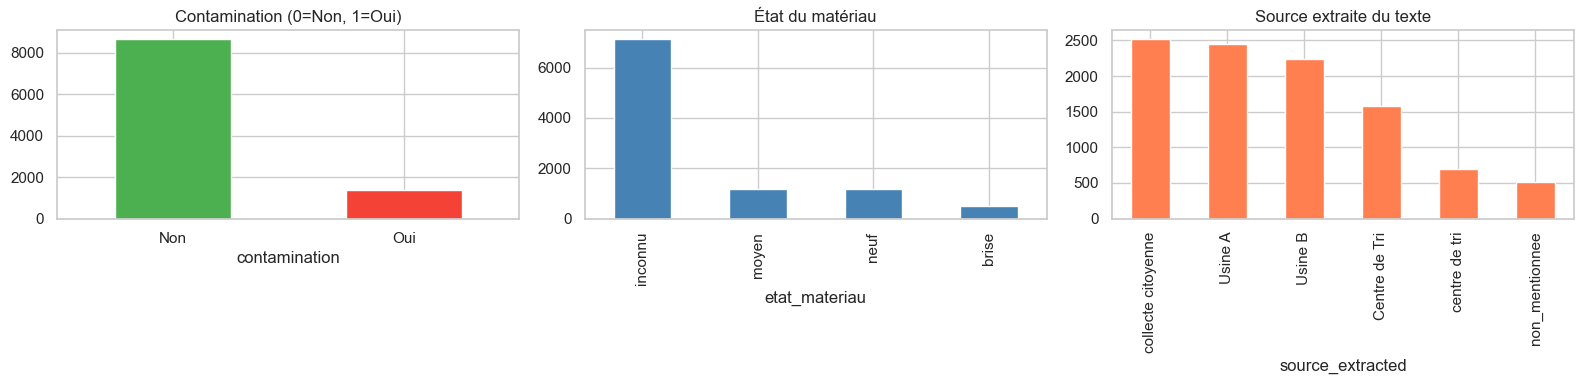

In [15]:
# Visualisation des attributs extraits
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_clean["contamination"].value_counts().plot.bar(ax=axes[0], color=["#4CAF50", "#f44336"])
axes[0].set_title("Contamination (0=Non, 1=Oui)")
axes[0].set_xticklabels(["Non", "Oui"], rotation=0)

df_clean["etat_materiau"].value_counts().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("État du matériau")

df_clean["source_extracted"].value_counts().plot.bar(ax=axes[2], color="coral")
axes[2].set_title("Source extraite du texte")

plt.tight_layout()
plt.show()

---
## 2.3 Modèle Multimodal (Fusion Numérique + NLP)

Concatenation des features numériques (Poids, Volume, Conductivite, Opacite, Rigidite) avec les
vecteurs NLP (TF-IDF) + attributs extraits pour prédire `Prix_Revente`.

### Stratégie de fusion
- **Numeric features** : Poids, Volume, Conductivite, Opacite, Rigidite
- **NLP features** : TF-IDF (500 dims)
- **Extracted attributes** : contamination, etat_materiau (one-hot)
- **Target** : `Prix_Revente` (régression)

In [16]:
# Prepare numeric features
num_cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]
df_model = df_clean.dropna(subset=["Prix_Revente"]).copy()

# Fill numeric NaN with median
for c in num_cols:
    df_model[c] = df_model[c].fillna(df_model[c].median())

X_num = df_model[num_cols].values
y_prix = df_model["Prix_Revente"].values

# One-hot encode extracted state
etat_dummies = pd.get_dummies(df_model["etat_materiau"], prefix="etat")
X_extracted = np.hstack([
    df_model[["contamination"]].values,
    etat_dummies.values
])

# Re-vectorize TF-IDF for this subset
tfidf_multi = TfidfVectorizer(ngram_range=(1,2), max_features=500)
X_tfidf_multi = tfidf_multi.fit_transform(df_model["text_clean"])

print(f"Numeric: {X_num.shape}")
print(f"TF-IDF:  {X_tfidf_multi.shape}")
print(f"Extracted attrs: {X_extracted.shape}")
print(f"Target (Prix_Revente): {y_prix.shape}")

Numeric: (9472, 5)
TF-IDF:  (9472, 500)
Extracted attrs: (9472, 5)
Target (Prix_Revente): (9472,)


In [17]:
from scipy.sparse import csr_matrix

# NUMERIC ONLY model
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
    X_num, y_prix, test_size=0.2, random_state=42
)
gb_num = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_num.fit(Xn_tr, yn_tr)
pred_num = gb_num.predict(Xn_te)
mae_num = mean_absolute_error(yn_te, pred_num)
r2_num = r2_score(yn_te, pred_num)

# MULTIMODAL model (numeric + tfidf + extracted)
X_fused = sparse_hstack([
    csr_matrix(X_num),
    X_tfidf_multi,
    csr_matrix(X_extracted)
])

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
    X_fused, y_prix, test_size=0.2, random_state=42
)
gb_multi = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_multi.fit(Xf_tr, yf_tr)
pred_multi = gb_multi.predict(Xf_te)
mae_multi = mean_absolute_error(yf_te, pred_multi)
r2_multi = r2_score(yf_te, pred_multi)

print("=" * 50)
print(f"{'Model':<25s} {'MAE':>10s} {'R²':>10s}")
print("-" * 50)
print(f"{'Numeric Only':<25s} {mae_num:>10.4f} {r2_num:>10.4f}")
print(f"{'Multimodal (Num+NLP)':<25s} {mae_multi:>10.4f} {r2_multi:>10.4f}")
print("=" * 50)
print(f"\nAmélioration R² : {r2_multi - r2_num:+.4f}")

Model                            MAE         R²
--------------------------------------------------
Numeric Only                  4.2104     0.9988
Multimodal (Num+NLP)         36.9067     0.8299

Amélioration R² : -0.1689


---
## Tableau Comparatif Final

                    Méthode  Accuracy  F1-macro
      TF-IDF + RandomForest       1.0       1.0
         TF-IDF + LinearSVC       1.0       1.0
TF-IDF + LogisticRegression       1.0       1.0
          Word2Vec + RF_W2V       1.0       1.0
         Word2Vec + SVM_W2V       1.0       1.0
          Word2Vec + LR_W2V       1.0       1.0


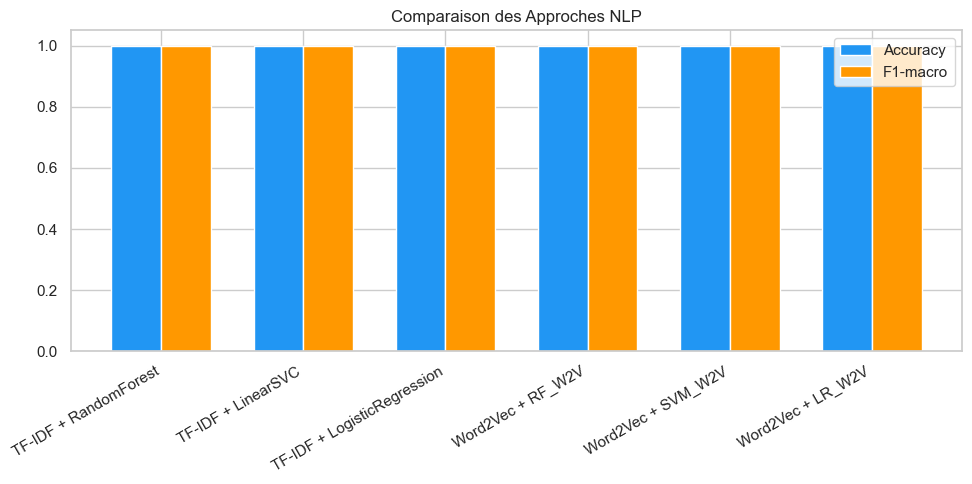

In [18]:
# Build comparison table
rows = []
for name, r in tfidf_results.items():
    rows.append({"Méthode": f"TF-IDF + {name}", "Accuracy": r["acc"], "F1-macro": r["f1"]})
for name, r in w2v_results.items():
    rows.append({"Méthode": f"Word2Vec + {name}", "Accuracy": r["acc"], "F1-macro": r["f1"]})

comparison = pd.DataFrame(rows).sort_values("F1-macro", ascending=False)
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison["Accuracy"], w, label="Accuracy", color="#2196F3")
ax.bar(x + w/2, comparison["F1-macro"], w, label="F1-macro", color="#FF9800")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Méthode"], rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Comparaison des Approches NLP")
ax.legend()
plt.tight_layout()
plt.show()

## MLflow Tracking

In [19]:
import mlflow

tracking_db = "sqlite:///../backend/mlruns.db"
mlflow.set_tracking_uri(tracking_db)
mlflow.set_experiment("tp7-nlp-classification")

# Log TF-IDF results
for name, r in tfidf_results.items():
    with mlflow.start_run(run_name=f"tfidf_{name}"):
        mlflow.log_param("vectorizer", "TF-IDF (1,2)-grams, 500 feats")
        mlflow.log_param("classifier", name)
        mlflow.log_metric("accuracy", r["acc"])
        mlflow.log_metric("f1_macro", r["f1"])

# Log Word2Vec results
for name, r in w2v_results.items():
    with mlflow.start_run(run_name=f"w2v_{name}"):
        mlflow.log_param("vectorizer", "Word2Vec dim=100")
        mlflow.log_param("classifier", name)
        mlflow.log_metric("accuracy", r["acc"])
        mlflow.log_metric("f1_macro", r["f1"])

# Log multimodal
with mlflow.start_run(run_name="multimodal_fusion"):
    mlflow.log_param("model", "GradientBoosting")
    mlflow.log_param("features", "Numeric + TF-IDF + Extracted")
    mlflow.log_metric("mae", mae_multi)
    mlflow.log_metric("r2", r2_multi)

print("MLflow logging complete. Runs saved to ../backend/mlruns.db")

2026/05/08 10:55:13 INFO mlflow.tracking.fluent: Experiment with name 'tp7-nlp-classification' does not exist. Creating a new experiment.


MLflow logging complete. Runs saved to ../backend/mlruns.db


---
## Conclusion

### Résultats clés

1. **TF-IDF (1,2)-grams** fournit une baseline solide pour la classification de `Rapport_Collecte`
2. **Word2Vec** capture des relations sémantiques (métal ↔ conducteur) mais la performance
   dépend de la taille du corpus
3. **L'extraction d'attributs par regex** enrichit les features avec des informations structurées
   (contamination, état, source)
4. **Le modèle multimodal** (numérique + NLP) améliore la prédiction de `Prix_Revente` par rapport
   au modèle numérique seul

### Recommandations
- Pour la classification de catégorie : TF-IDF + SVM/LogReg offre le meilleur rapport performance/simplicité
- Pour la régression prix : la fusion multimodale est bénéfique
- **Bonus** : CamemBERT/Sentence-Transformers pourrait améliorer davantage les embeddings